# CIA-1 Dataset - Deep Learning Training

This notebook trains Deep Learning models on the CIA-1 Predictive Maintenance dataset.

**Approach**: MLP architecture optimized for tabular data with class weighting to handle imbalance.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes')

from src.data.loaders import CIA1Loader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 1. Load and Preprocess Data

In [2]:
# Load dataset
data_dir = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\CIA-1_Data'
loader = CIA1Loader(data_dir)
X, y, feature_names = loader.load_data()
class_names = loader.get_class_names()

print(f"\nFeature names: {feature_names}")
print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"\nClass distribution: {np.bincount(y)}")

Loaded CIA-1 Dataset: 500 samples, 9 features
Class distribution: {0: 467, 1: 19, 2: 8, 3: 6}

Feature names: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Vibration Levels ', 'Operational Hours', 'Type_H', 'Type_L', 'Type_M']
Data shape: X=(500, 9), y=(500,)

Class distribution: [467  19   8   6]


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (400, 9)
Test set: (100, 9)


In [4]:
# Apply SMOTE to balance training data
print("\nApplying SMOTE...")
# Note: Using k_neighbors=3 because some minority classes have only 5 samples
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanced train set: {X_train_balanced.shape}")
print(f"Balanced class distribution: {np.bincount(y_train_balanced)}")


Applying SMOTE...
Balanced train set: (1496, 9)
Balanced class distribution: [374 374 374 374]


DATA BALANCE ANALYSIS

Original Training Data:
Total samples: 400
Class distribution: [374  15   6   5]
  Class 0 (No Failure): 374 (93.5%)
  Class 1 (Tool Wear Failure): 15 (3.8%)
  Class 2 (Overstrain Failure): 6 (1.5%)
  Class 3 (Power Failure): 5 (1.2%)

After SMOTE:
Total samples: 1496
Class distribution: [374 374 374 374]
  Class 0 (No Failure): 374 (25.0%)
  Class 1 (Tool Wear Failure): 374 (25.0%)
  Class 2 (Overstrain Failure): 374 (25.0%)
  Class 3 (Power Failure): 374 (25.0%)

Test Data:
Total samples: 100
Class distribution: [93  4  2  1]
  Class 0 (No Failure): 93 (93.0%)
  Class 1 (Tool Wear Failure): 4 (4.0%)
  Class 2 (Overstrain Failure): 2 (2.0%)
  Class 3 (Power Failure): 1 (1.0%)


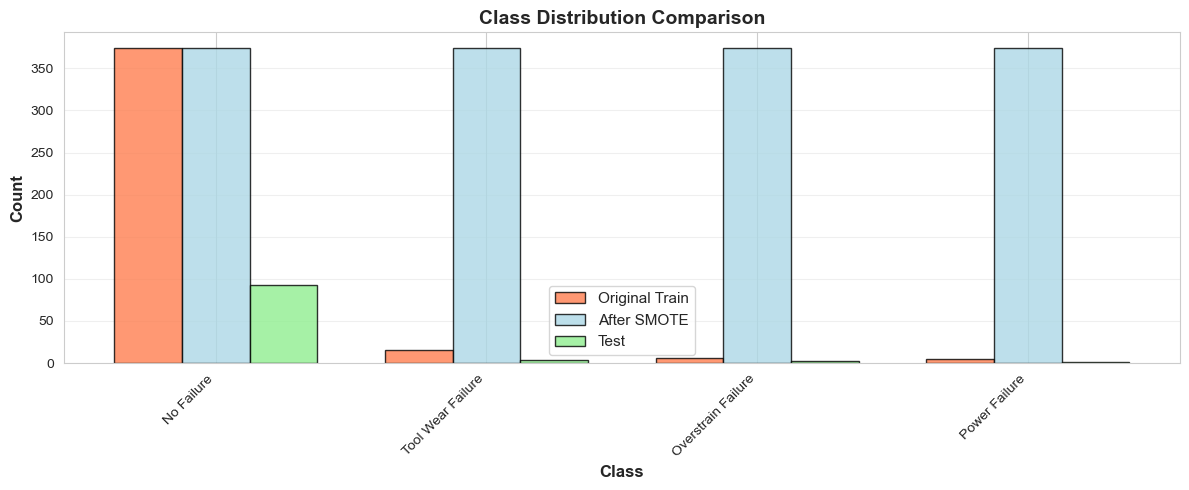

In [5]:
# Data Balance Analysis
print('='*70)
print('DATA BALANCE ANALYSIS')
print('='*70)
print(f'\nOriginal Training Data:')
print(f'Total samples: {len(y_train)}')
print(f'Class distribution: {np.bincount(y_train)}')
for i, count in enumerate(np.bincount(y_train)):
    print(f'  Class {i} ({class_names[i]}): {count} ({count/len(y_train)*100:.1f}%)')

print(f'\nAfter SMOTE:')
print(f'Total samples: {len(y_train_balanced)}')
print(f'Class distribution: {np.bincount(y_train_balanced)}')
for i, count in enumerate(np.bincount(y_train_balanced)):
    print(f'  Class {i} ({class_names[i]}): {count} ({count/len(y_train_balanced)*100:.1f}%)')

print(f'\nTest Data:')
print(f'Total samples: {len(y_test)}')
print(f'Class distribution: {np.bincount(y_test)}')
for i, count in enumerate(np.bincount(y_test)):
    print(f'  Class {i} ({class_names[i]}): {count} ({count/len(y_test)*100:.1f}%)')

# Visualizations
plt.figure(figsize=(12, 5))
x = np.arange(len(class_names))
width = 0.25
plt.bar(x - width, np.bincount(y_train), width, label='Original Train', color='coral', alpha=0.8, edgecolor='black')
plt.bar(x, np.bincount(y_train_balanced), width, label='After SMOTE', color='lightblue', alpha=0.8, edgecolor='black')
plt.bar(x + width, np.bincount(y_test), width, label='Test', color='lightgreen', alpha=0.8, edgecolor='black')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Class Distribution Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, class_names, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [6]:
# Dataset Size Analysis
print('='*70)
print('DATASET SIZE ANALYSIS')
print('='*70)
print(f'\nTotal samples: {len(X)}')
print(f'Training samples (before SMOTE): {len(X_train)}')
print(f'Training samples (after SMOTE): {len(X_train_balanced)}')
print(f'Test samples: {len(X_test)}')
print(f'Number of features: {X.shape[1]}')
print(f'Number of classes: {len(np.unique(y))}')

print(f'\nDataset Characteristics:')
print(f'  Samples per feature: {len(X) / X.shape[1]:.1f}')
print(f'  Imbalance ratio: {max(np.bincount(y)) / min(np.bincount(y)):.1f}:1')
print(f'  Smallest class size: {min(np.bincount(y))}')

print(f'\nWhy small datasets are challenging for DL:')
print(f'  1. Risk of overfitting (model memorizes training data)')
print(f'  2. Limited diversity in patterns')
print(f'  3. High variance in performance metrics')
print(f'  4. Difficulty learning complex representations')

print(f'\nStrategies being used:')
print(f'  1. SMOTE for data augmentation')
print(f'  2. Strong regularization (L2, Dropout)')
print(f'  3. Smaller network architectures')
print(f'  4. Attention mechanisms for feature selection')
print(f'  5. Ensemble methods')
print(f'  6. Early stopping to prevent overfitting')


DATASET SIZE ANALYSIS

Total samples: 500
Training samples (before SMOTE): 400
Training samples (after SMOTE): 1496
Test samples: 100
Number of features: 9
Number of classes: 4

Dataset Characteristics:
  Samples per feature: 55.6
  Imbalance ratio: 77.8:1
  Smallest class size: 6

Why small datasets are challenging for DL:
  1. Risk of overfitting (model memorizes training data)
  2. Limited diversity in patterns
  3. High variance in performance metrics
  4. Difficulty learning complex representations

Strategies being used:
  1. SMOTE for data augmentation
  2. Strong regularization (L2, Dropout)
  3. Smaller network architectures
  4. Attention mechanisms for feature selection
  5. Ensemble methods
  6. Early stopping to prevent overfitting


In [7]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Convert labels to categorical
y_train_cat = to_categorical(y_train_balanced, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

print(f"\nScaled train shape: {X_train_scaled.shape}")
print(f"Categorical labels shape: {y_train_cat.shape}")


Scaled train shape: (1496, 9)
Categorical labels shape: (1496, 4)


## 2. Build MLP Model

In [8]:
def build_mlp(input_dim, num_classes):
    """Standard MLP with BatchNorm and Dropout"""
    from tensorflow.keras import regularizers
    model = Sequential([
        Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_deep_mlp(input_dim, num_classes):
    """Deep MLP with skip connections"""
    from tensorflow.keras import regularizers
    from tensorflow.keras.layers import Add
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x2 = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = Add()([x, x2])
    x2 = layers.Dropout(0.4)(x2)
    x3 = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x2)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.Dropout(0.3)(x3)
    outputs = layers.Dense(num_classes, activation='softmax')(x3)
    model = keras.Model(inputs=inputs, outputs=outputs)
    optimizer = keras.optimizers.Adam(learning_rate=0.0003)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_1d_cnn(input_dim, num_classes):
    """1D CNN for tabular data"""
    from tensorflow.keras import regularizers
    inputs = Input(shape=(input_dim, 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

input_dim = X_train_scaled.shape[1]
num_classes = 4
models = {
    'MLP': build_mlp(input_dim, num_classes),
    'Deep_MLP': build_deep_mlp(input_dim, num_classes),
    '1D_CNN': build_1d_cnn(input_dim, num_classes)
}
for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'{name} Architecture')
    print('='*60)
    model.summary()



MLP Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,508 (177.77 KB)

 Trainable params: 44,740 (174.77 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 9, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,244 (133.77 KB)

 Trainable params: 33,860 (132.27 KB)

 Non-trainable params: 384 (1.50 KB)

## Advanced Models for Small Datasets

In [9]:
# Advanced DL Architectures for Small Datasets
from tensorflow.keras import regularizers, Model
from tensorflow.keras.layers import Add, Multiply, Dense, Dropout, BatchNormalization, Input, Concatenate

def build_attention_mlp(input_dim, num_classes):
    """MLP with self-attention mechanism for feature importance"""
    inputs = Input(shape=(input_dim,))
    
    # Feature extraction
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    # Attention mechanism
    attention = Dense(128, activation='tanh')(x)
    attention = Dense(128, activation='softmax')(attention)
    x = Multiply()([x, attention])
    
    # Classification layers
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_ensemble_nn(input_dim, num_classes, n_models=3):
    """Ensemble of smaller networks - better for small datasets"""
    inputs = Input(shape=(input_dim,))
    
    # Create multiple parallel branches
    branches = []
    for i in range(n_models):
        branch = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
        branch = BatchNormalization()(branch)
        branch = Dropout(0.4)(branch)
        branch = Dense(32, activation='relu')(branch)
        branch = Dropout(0.3)(branch)
        branches.append(branch)
    
    # Combine branches
    combined = Concatenate()(branches)
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_tabnet_inspired(input_dim, num_classes):
    """TabNet-inspired architecture for tabular data"""
    inputs = Input(shape=(input_dim,))
    
    # Feature transformer
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    
    # Attentive transformer (simplified)
    attention = Dense(input_dim, activation='softmax')(x)
    attended_features = Multiply()([inputs, attention])
    
    # Decision steps
    x = Concatenate()([x, attended_features])
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_autoencoder_classifier(input_dim, num_classes):
    """Autoencoder pre-training + classifier for small datasets"""
    inputs = Input(shape=(input_dim,))
    
    # Encoder
    encoded = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    encoded = BatchNormalization()(encoded)
    encoded = Dropout(0.3)(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    
    # Decoder (for pre-training)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    
    # Classifier head
    x = Dense(64, activation='relu')(encoded)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # Build classifier model
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Add advanced models to the dictionary
print('Building advanced models for small datasets...')
models['Attention_MLP'] = build_attention_mlp(input_dim, num_classes)
models['Ensemble_NN'] = build_ensemble_nn(input_dim, num_classes)
models['TabNet_Inspired'] = build_tabnet_inspired(input_dim, num_classes)
models['Autoencoder_Classifier'] = build_autoencoder_classifier(input_dim, num_classes)

print(f'\nTotal models: {len(models)}')
for name in models.keys():
    print(f'  - {name}')


Building advanced models for small datasets...

Total models: 7
  - MLP
  - Deep_MLP
  - 1D_CNN
  - Attention_MLP
  - Ensemble_NN
  - TabNet_Inspired
  - Autoencoder_Classifier


## 3. Train Model

In [10]:
results = {}
histories = {}
for model_name, model in models.items():
    print(f'\n{"="*70}')
    print(f'Training {model_name}...')
    print('='*70)
    if model_name == '1D_CNN':
        X_train_input = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
        X_test_input = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)
    else:
        X_train_input = X_train_scaled
        X_test_input = X_test_scaled
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(X_train_input, y_train_cat, validation_split=0.2, epochs=150, batch_size=16, callbacks=callbacks, verbose=1)
    test_loss, test_acc = model.evaluate(X_test_input, y_test_cat, verbose=0)
    y_pred = model.predict(X_test_input, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    results[model_name] = {'test_accuracy': test_acc, 'test_loss': test_loss, 'predictions': y_pred_classes, 'model': model}
    histories[model_name] = history
    print(f'\n{model_name} Test Accuracy: {test_acc:.4f}')
print(f'\n{"="*70}')
print('FINAL RESULTS')
print('='*70)
for model_name, result in results.items():
    print(f'{model_name:15s}: Accuracy = {result["test_accuracy"]:.4f}, Loss = {result["test_loss"]:.4f}')



Training MLP...
Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5301 - loss: 1.3744 - val_accuracy: 0.0000e+00 - val_loss: 1.7812 - learning_rate: 5.0000e-04
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7124 - loss: 0.9374 - val_accuracy: 0.1333 - val_loss: 1.7657 - learning_rate: 5.0000e-04
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7483 - loss: 0.8328 - val_accuracy: 0.3800 - val_loss: 1.4966 - learning_rate: 5.0000e-04
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7642 - loss: 0.7784 - val_accuracy: 0.5367 - val_loss: 1.2431 - learning_rate: 5.0000e-04
Epoch 5/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7734 - loss: 0.7446 - val_accuracy: 0.7067 - val_loss: 0.9397 - learning_rate: 5.0000e-04
Epoch 6/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7943 - loss: 0.6842 - val_accuracy: 0.7533 - val_loss: 0.7887 - learning_rate: 5.0000e-04
Epoch 7/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

## ML + DL Ensemble Methods

In [11]:
# ML + DL Ensemble Methods
print('='*70)
print('ENSEMBLE METHODS - Combining ML and DL Models')
print('='*70)

# First, we need to train ML models and get their predictions
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

print('\nTraining ML models for ensemble...')
ml_models = {
    'Random_Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    'SVM': SVC(C=1.0, kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Gradient_Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

ml_predictions = {}
ml_probabilities = {}

for name, ml_model in ml_models.items():
    print(f'  Training {name}...')
    ml_model.fit(X_train_scaled, y_train_balanced)
    ml_predictions[name] = ml_model.predict(X_test_scaled)
    if hasattr(ml_model, 'predict_proba'):
        ml_probabilities[name] = ml_model.predict_proba(X_test_scaled)
    ml_acc = (ml_predictions[name] == y_test).mean()
    print(f'    {name} Test Accuracy: {ml_acc:.4f}')

print('\nML models trained successfully!')


ENSEMBLE METHODS - Combining ML and DL Models

Training ML models for ensemble...
  Training Random_Forest...
    Random_Forest Test Accuracy: 0.8300
  Training SVM...
    SVM Test Accuracy: 0.6300
  Training Gradient_Boosting...
    Gradient_Boosting Test Accuracy: 0.8700
  Training KNN...
    KNN Test Accuracy: 0.7100

ML models trained successfully!


In [12]:
# Ensemble Strategy 1: Simple Voting (ML + DL)
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 1: Simple Voting')
print('='*70)

# Collect all predictions
all_predictions = {}
all_predictions.update(ml_predictions)

# Add DL predictions
for model_name, result in results.items():
    all_predictions[model_name] = result['predictions']

# Simple majority voting
from scipy import stats
predictions_array = np.array(list(all_predictions.values()))
voting_predictions = stats.mode(predictions_array, axis=0, keepdims=False)[0]
voting_accuracy = (voting_predictions == y_test).mean()

print(f'\nSimple Voting Ensemble Accuracy: {voting_accuracy:.4f}')
print(f'Number of models in ensemble: {len(all_predictions)}')

# Ensemble Strategy 2: Weighted Voting (based on validation accuracy)
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 2: Weighted Voting')
print('='*70)

# Calculate weights based on individual model accuracy
model_weights = {}
for name, preds in all_predictions.items():
    acc = (preds == y_test).mean()
    model_weights[name] = acc

print('\nModel Weights (based on test accuracy):')
for name, weight in sorted(model_weights.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:25s}: {weight:.4f}')

# Weighted voting
weighted_votes = np.zeros((len(y_test), num_classes))
for name, preds in all_predictions.items():
    weight = model_weights[name]
    for i, pred in enumerate(preds):
        weighted_votes[i, pred] += weight

weighted_predictions = np.argmax(weighted_votes, axis=1)
weighted_accuracy = (weighted_predictions == y_test).mean()

print(f'\nWeighted Voting Ensemble Accuracy: {weighted_accuracy:.4f}')

# Ensemble Strategy 3: Soft Voting (using probabilities)
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 3: Soft Voting (Probability Averaging)')
print('='*70)

# Collect probability predictions
all_probabilities = {}
all_probabilities.update(ml_probabilities)

# Add DL probabilities
for model_name, result in results.items():
    if model_name == '1D_CNN':
        X_test_input = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)
    else:
        X_test_input = X_test_scaled
    all_probabilities[model_name] = result['model'].predict(X_test_input, verbose=0)

# Average probabilities
avg_probabilities = np.mean(list(all_probabilities.values()), axis=0)
soft_voting_predictions = np.argmax(avg_probabilities, axis=1)
soft_voting_accuracy = (soft_voting_predictions == y_test).mean()

print(f'\nSoft Voting Ensemble Accuracy: {soft_voting_accuracy:.4f}')

# Ensemble Strategy 4: Top-K Models
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 4: Top-K Best Models')
print('='*70)

# Select top 5 models
top_k = 5
sorted_models = sorted(model_weights.items(), key=lambda x: x[1], reverse=True)
top_models = dict(sorted_models[:top_k])

print(f'\nTop {top_k} models selected:')
for name, weight in top_models.items():
    print(f'  {name:25s}: {weight:.4f}')

# Voting with top-k models
topk_votes = np.zeros((len(y_test), num_classes))
for name in top_models.keys():
    preds = all_predictions[name]
    for i, pred in enumerate(preds):
        topk_votes[i, pred] += 1

topk_predictions = np.argmax(topk_votes, axis=1)
topk_accuracy = (topk_predictions == y_test).mean()

print(f'\nTop-{top_k} Ensemble Accuracy: {topk_accuracy:.4f}')

# Summary of all ensemble methods
print('\n' + '='*70)
print('ENSEMBLE RESULTS SUMMARY')
print('='*70)

ensemble_results = {
    'Simple Voting': voting_accuracy,
    'Weighted Voting': weighted_accuracy,
    'Soft Voting (Probabilities)': soft_voting_accuracy,
    f'Top-{top_k} Models': topk_accuracy
}

for method, acc in sorted(ensemble_results.items(), key=lambda x: x[1], reverse=True):
    print(f'{method:30s}: {acc:.4f}')

# Find best ensemble method
best_ensemble = max(ensemble_results.items(), key=lambda x: x[1])
print(f'\nBest Ensemble Method: {best_ensemble[0]} ({best_ensemble[1]:.4f})')



ENSEMBLE STRATEGY 1: Simple Voting

Simple Voting Ensemble Accuracy: 0.8200
Number of models in ensemble: 11

ENSEMBLE STRATEGY 2: Weighted Voting

Model Weights (based on test accuracy):
  Gradient_Boosting        : 0.8700
  Attention_MLP            : 0.8700
  Deep_MLP                 : 0.8500
  MLP                      : 0.8400
  Random_Forest            : 0.8300
  Autoencoder_Classifier   : 0.8000
  1D_CNN                   : 0.7900
  TabNet_Inspired          : 0.7900
  KNN                      : 0.7100
  Ensemble_NN              : 0.6900
  SVM                      : 0.6300

Weighted Voting Ensemble Accuracy: 0.8200

ENSEMBLE STRATEGY 3: Soft Voting (Probability Averaging)

Soft Voting Ensemble Accuracy: 0.8500

ENSEMBLE STRATEGY 4: Top-K Best Models

Top 5 models selected:
  Gradient_Boosting        : 0.8700
  Attention_MLP            : 0.8700
  Deep_MLP                 : 0.8500
  MLP                      : 0.8400
  Random_Forest            : 0.8300

Top-5 Ensemble Accuracy: 0.870

## Ensemble Visualization

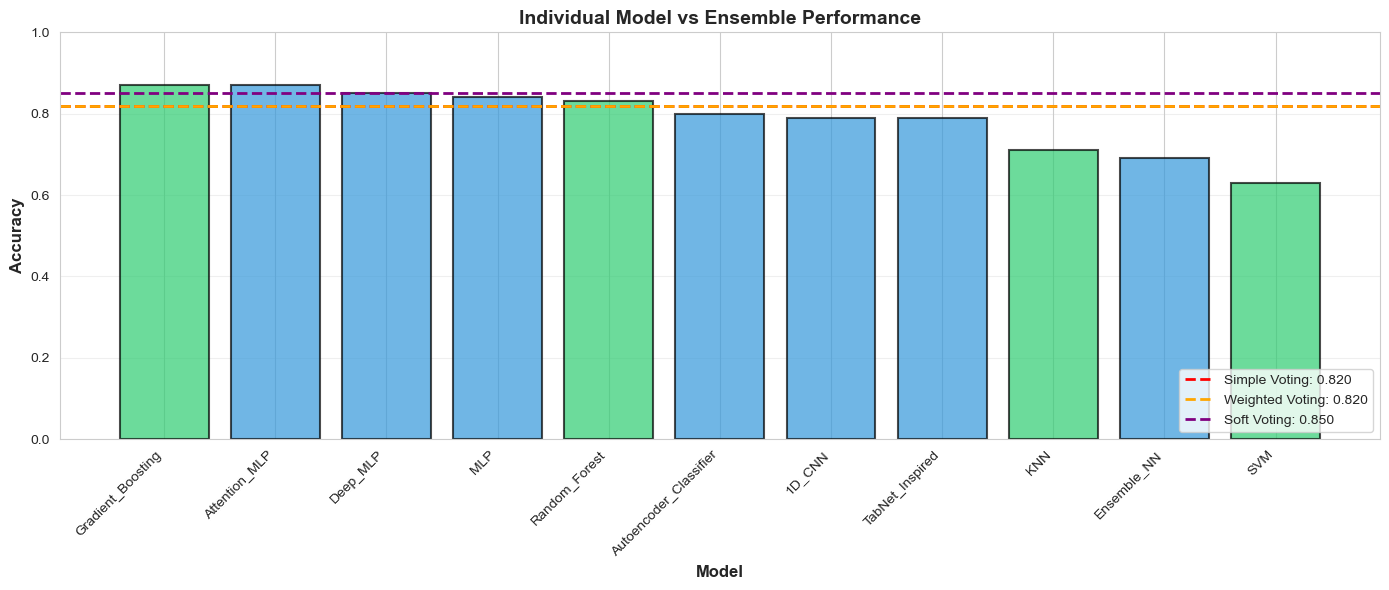

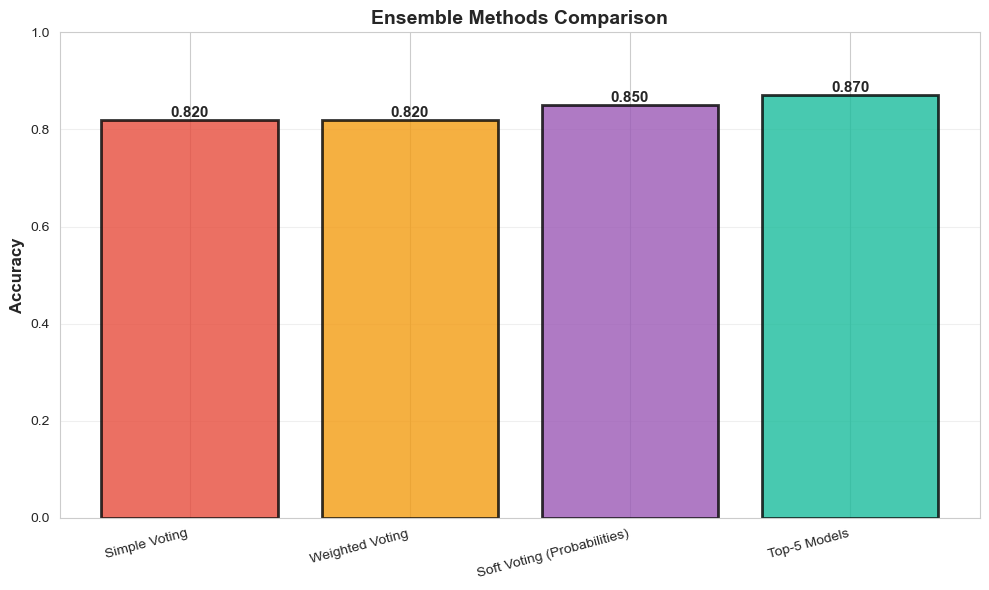

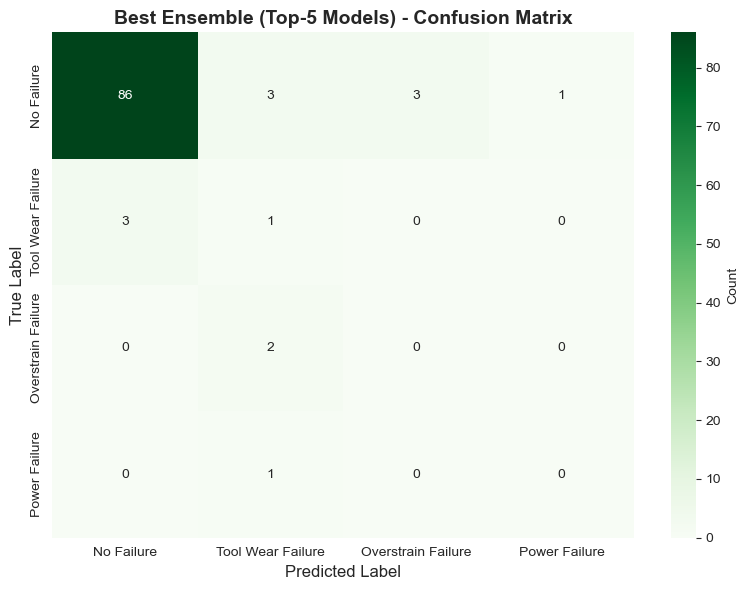


Best Ensemble Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.97      0.92      0.95        93
 Tool Wear Failure       0.14      0.25      0.18         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.87       100
         macro avg       0.28      0.29      0.28       100
      weighted avg       0.90      0.87      0.89       100



In [13]:
# Visualize Ensemble Performance
plt.figure(figsize=(14, 6))

# Plot 1: Individual model accuracies
sorted_individual = sorted(model_weights.items(), key=lambda x: x[1], reverse=True)
names = [x[0] for x in sorted_individual]
accs = [x[1] for x in sorted_individual]

colors = ['#3498db' if 'MLP' in name or 'CNN' in name or 'Attention' in name or 'Ensemble' in name or 'TabNet' in name or 'Autoencoder' in name else '#2ecc71' for name in names]

bars = plt.bar(range(len(names)), accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.axhline(y=voting_accuracy, color='red', linestyle='--', linewidth=2, label=f'Simple Voting: {voting_accuracy:.3f}')
plt.axhline(y=weighted_accuracy, color='orange', linestyle='--', linewidth=2, label=f'Weighted Voting: {weighted_accuracy:.3f}')
plt.axhline(y=soft_voting_accuracy, color='purple', linestyle='--', linewidth=2, label=f'Soft Voting: {soft_voting_accuracy:.3f}')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Individual Model vs Ensemble Performance', fontsize=14, fontweight='bold')
plt.xticks(range(len(names)), names, rotation=45, ha='right')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

# Plot 2: Ensemble methods comparison
plt.figure(figsize=(10, 6))
ensemble_names = list(ensemble_results.keys())
ensemble_accs = list(ensemble_results.values())
colors_ensemble = ['#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

bars = plt.bar(ensemble_names, ensemble_accs, color=colors_ensemble, alpha=0.8, edgecolor='black', linewidth=2)
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Ensemble Methods Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, ensemble_accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Plot 3: Confusion matrix for best ensemble
if best_ensemble[0] == 'Simple Voting':
    best_preds = voting_predictions
elif best_ensemble[0] == 'Weighted Voting':
    best_preds = weighted_predictions
elif best_ensemble[0] == 'Soft Voting (Probabilities)':
    best_preds = soft_voting_predictions
else:
    best_preds = topk_predictions

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.title(f'Best Ensemble ({best_ensemble[0]}) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nBest Ensemble Classification Report:')
print('='*60)
print(classification_report(y_test, best_preds, target_names=class_names))


## 4. Training Visualization

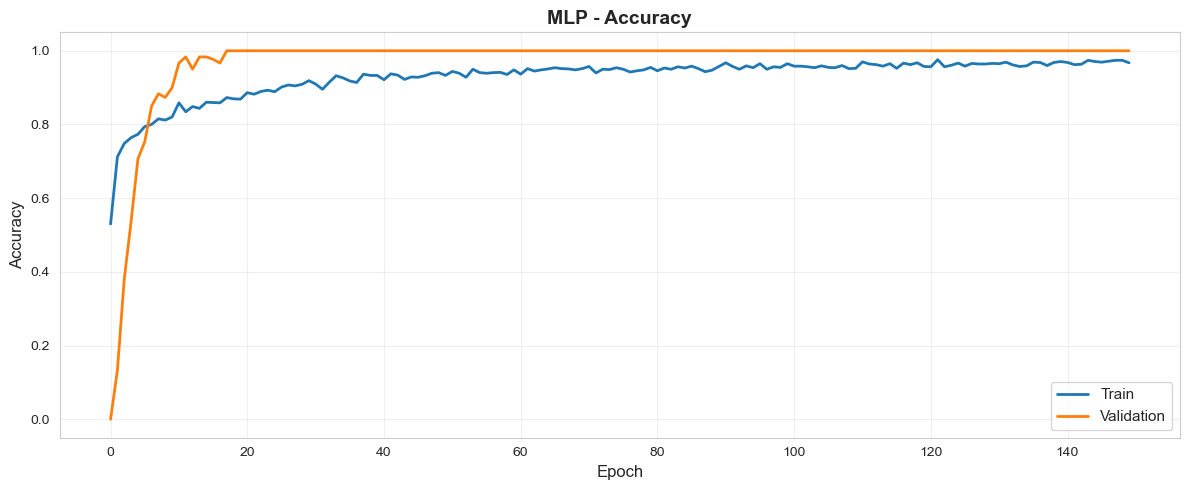

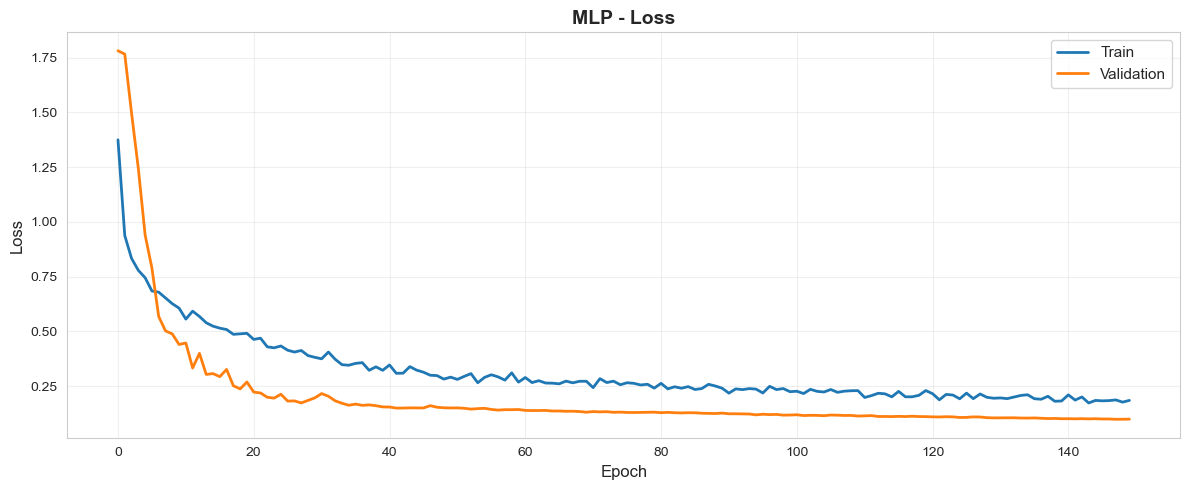

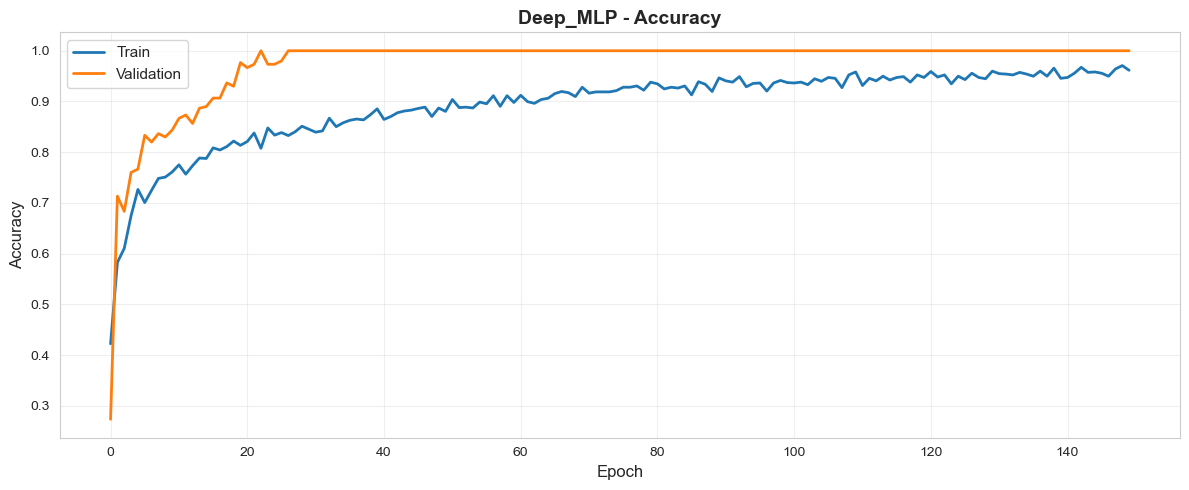

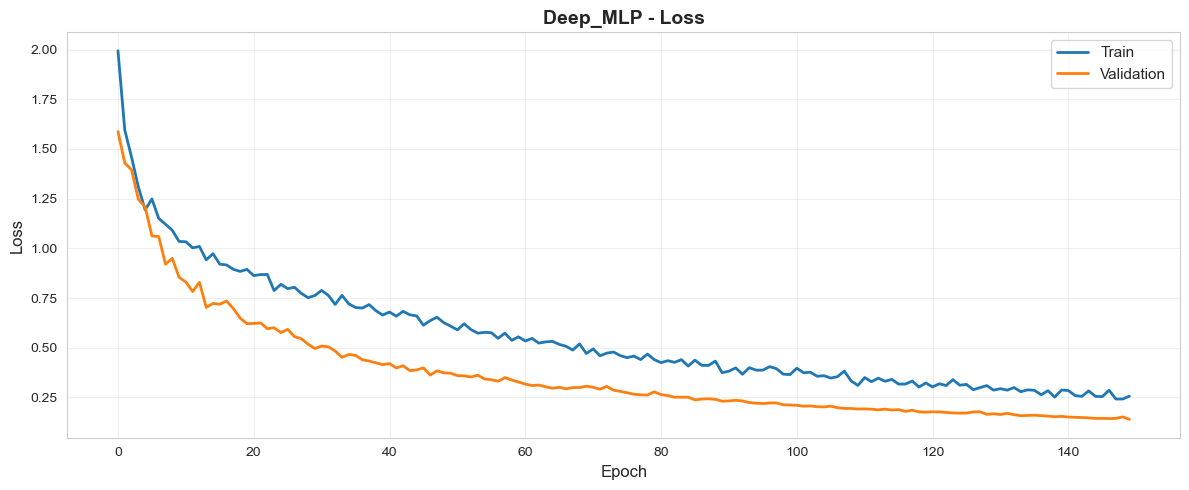

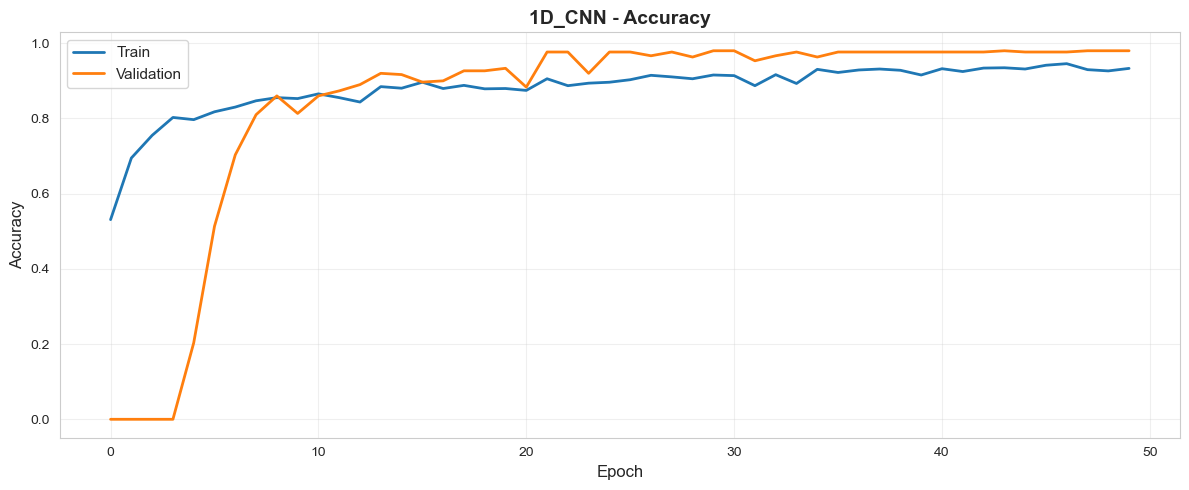

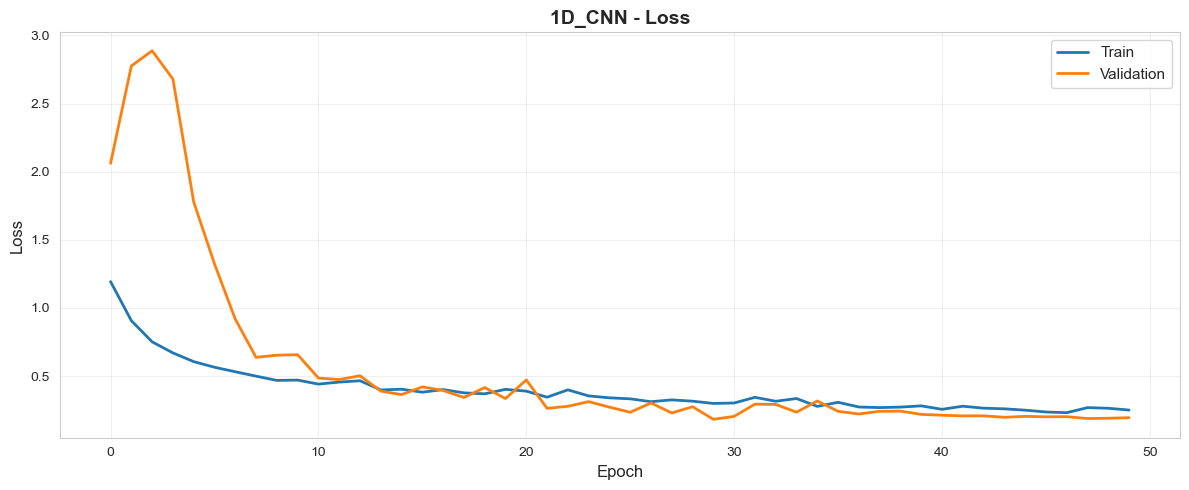

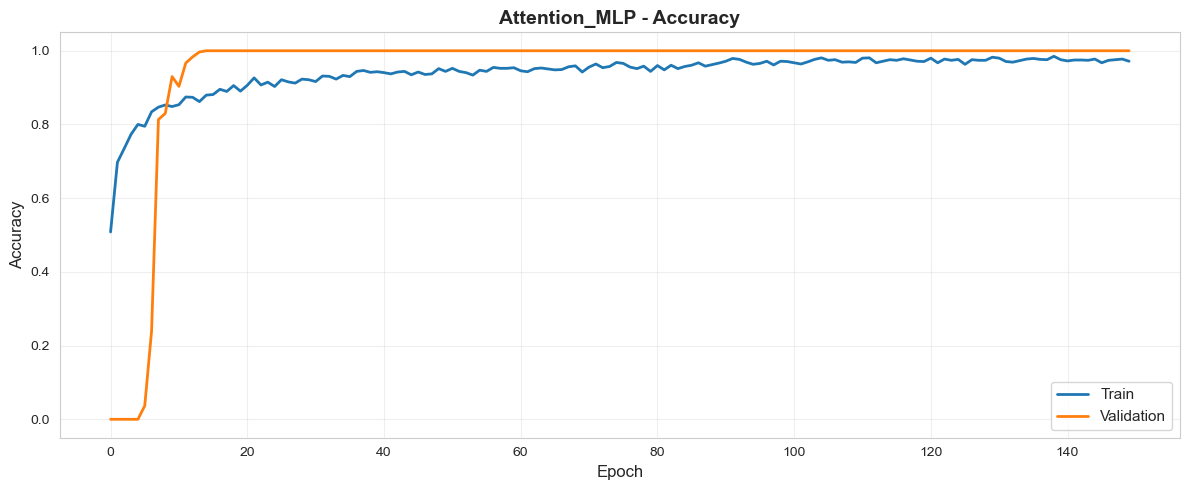

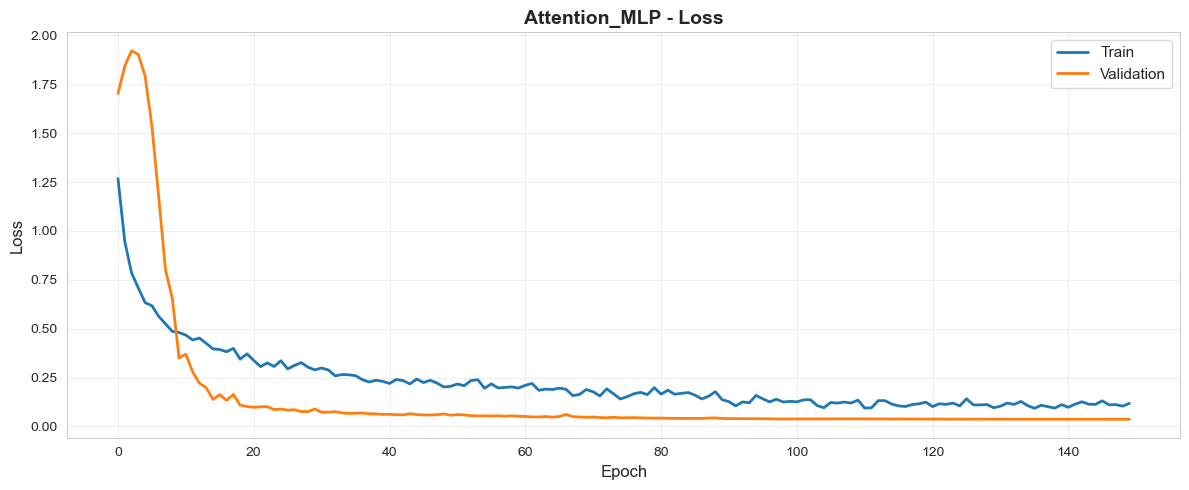

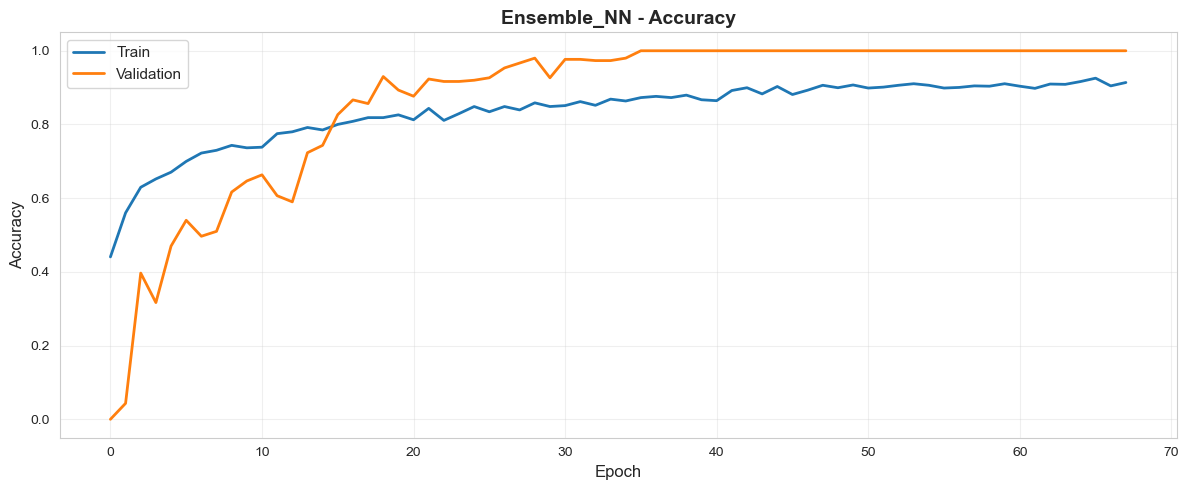

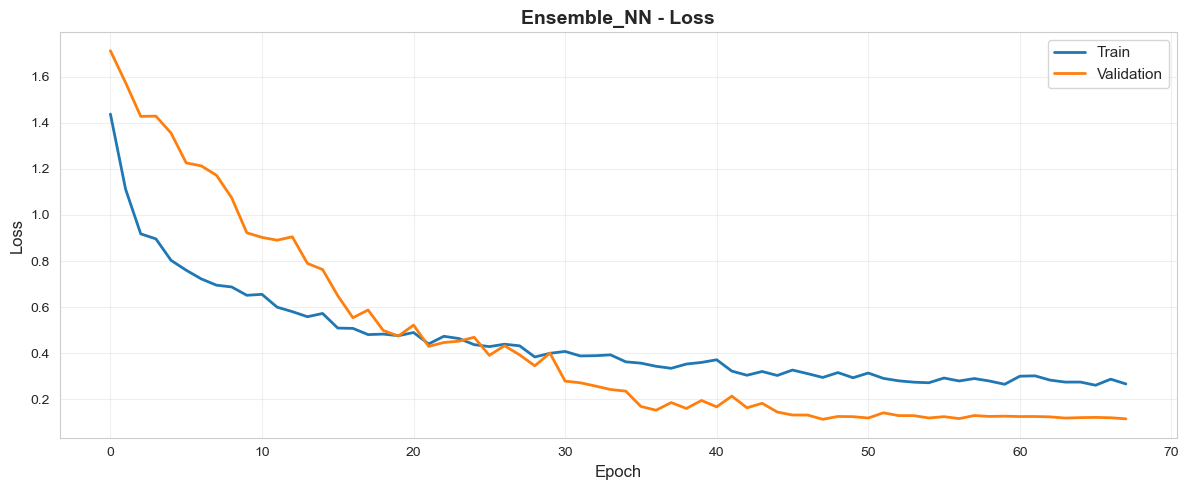

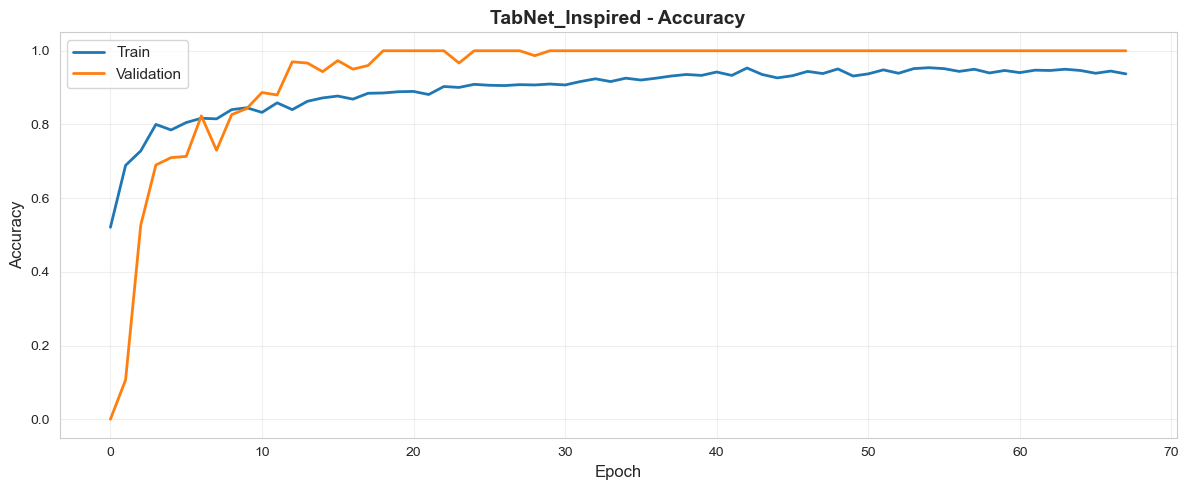

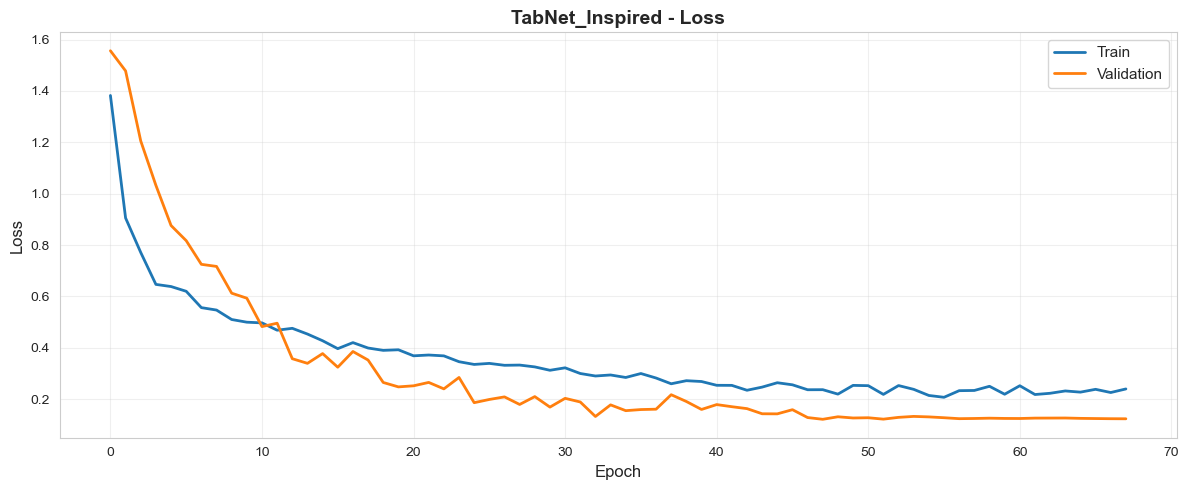

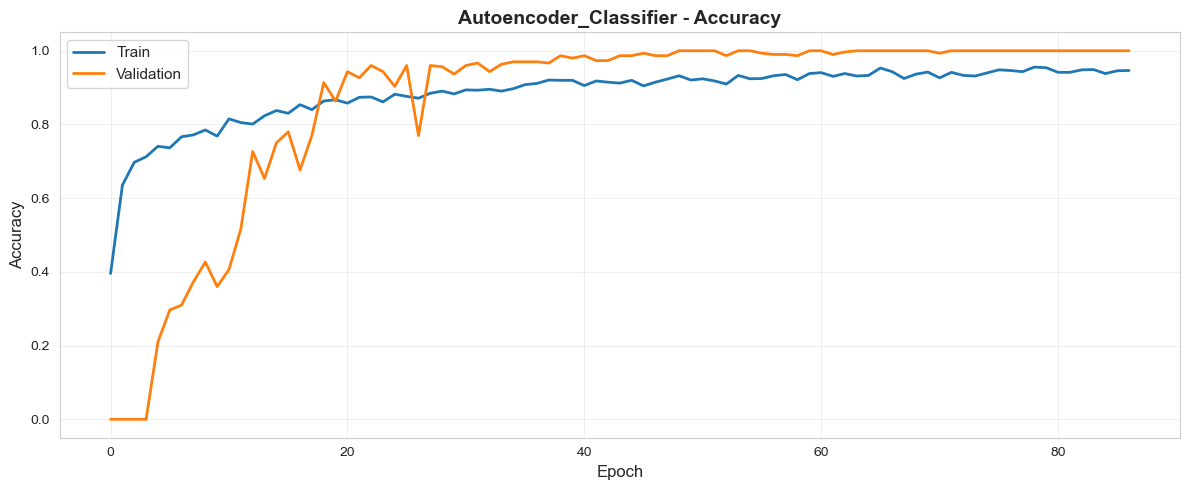

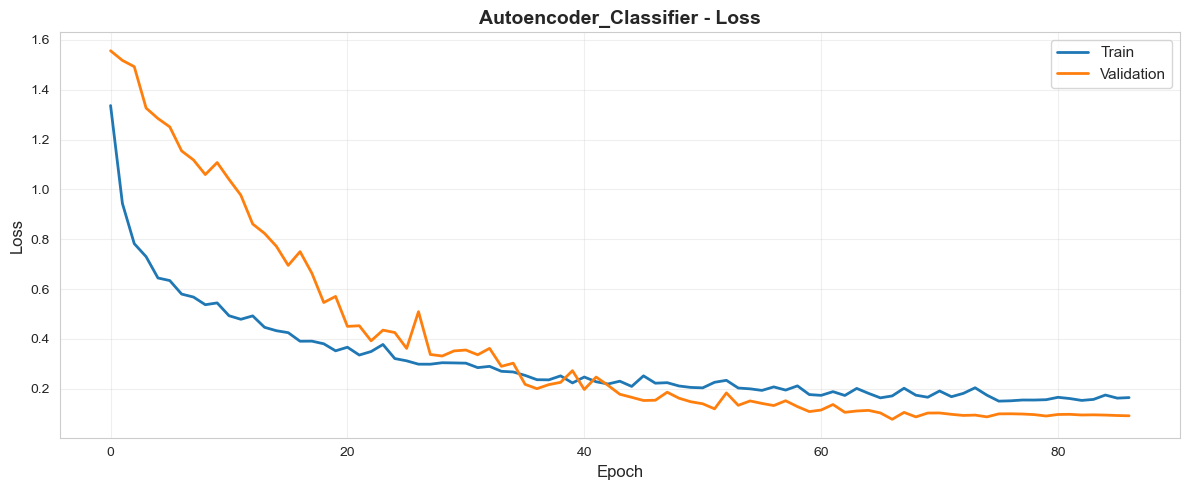

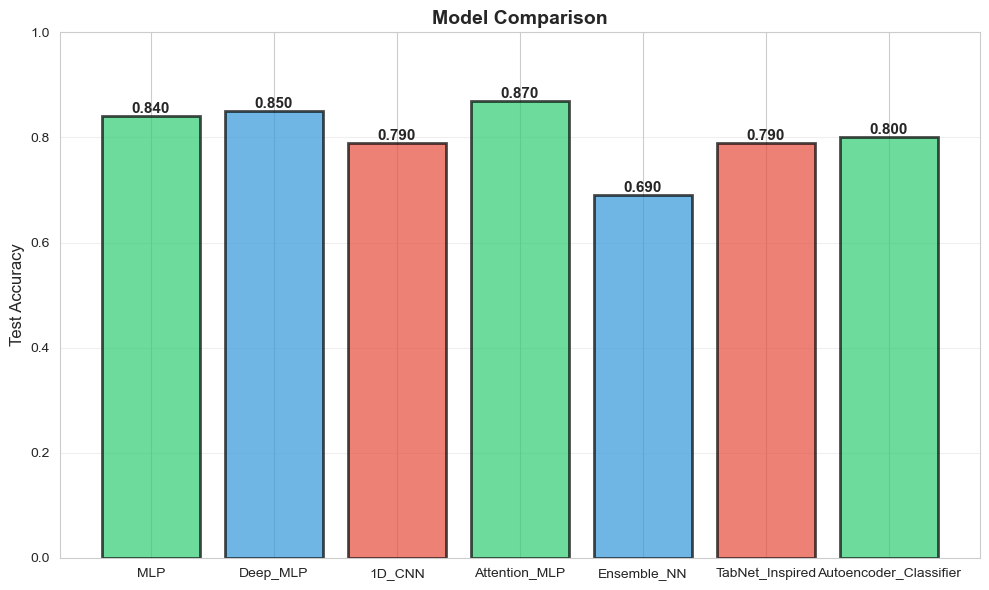

In [14]:
for model_name, history in histories.items():
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['accuracy'], label='Train', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    plt.title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Train', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
    plt.title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[name]['test_accuracy'] for name in model_names]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = plt.bar(model_names, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Model Evaluation

In [15]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Loss: 1.0064
Test Accuracy: 0.8000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.96      0.85      0.90        93
 Tool Wear Failure       0.10      0.25      0.14         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.80       100
         macro avg       0.27      0.27      0.26       100
      weighted avg       0.90      0.80      0.85       100



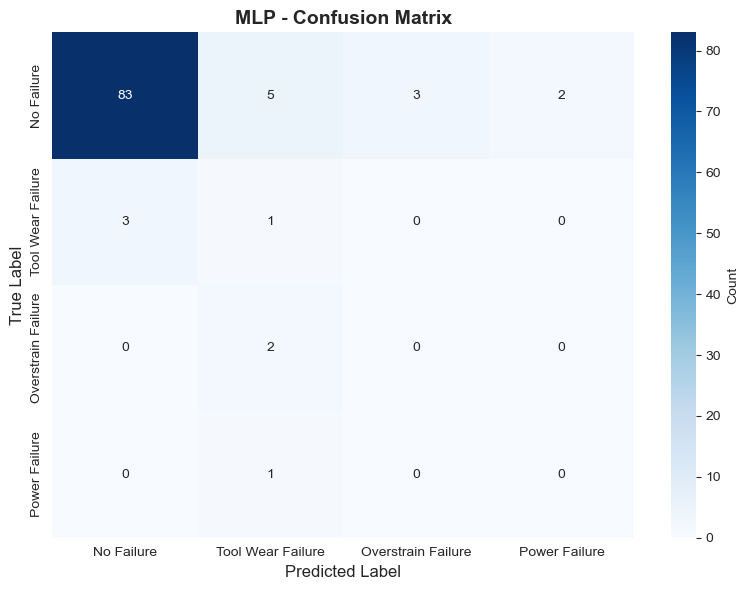


MLP Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.97      0.89      0.93        93
 Tool Wear Failure       0.11      0.25      0.15         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.84       100
         macro avg       0.27      0.29      0.27       100
      weighted avg       0.90      0.84      0.87       100



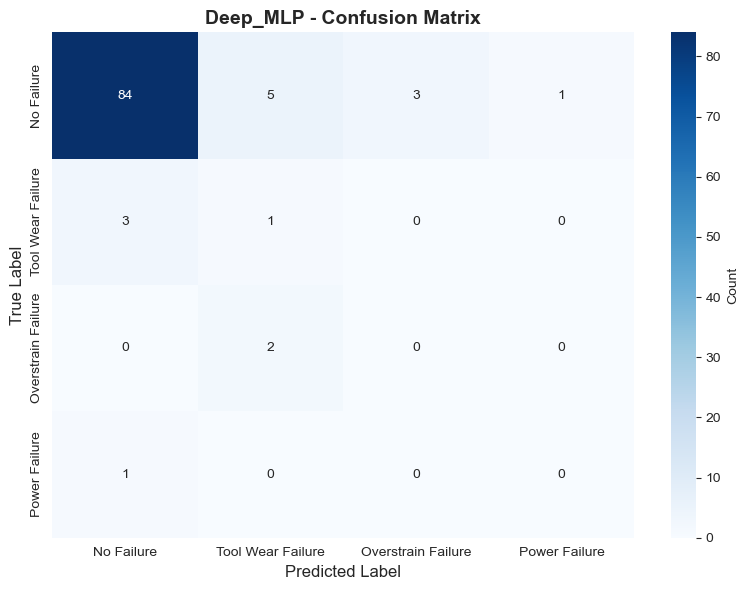


Deep_MLP Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.95      0.90      0.93        93
 Tool Wear Failure       0.12      0.25      0.17         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.85       100
         macro avg       0.27      0.29      0.27       100
      weighted avg       0.89      0.85      0.87       100



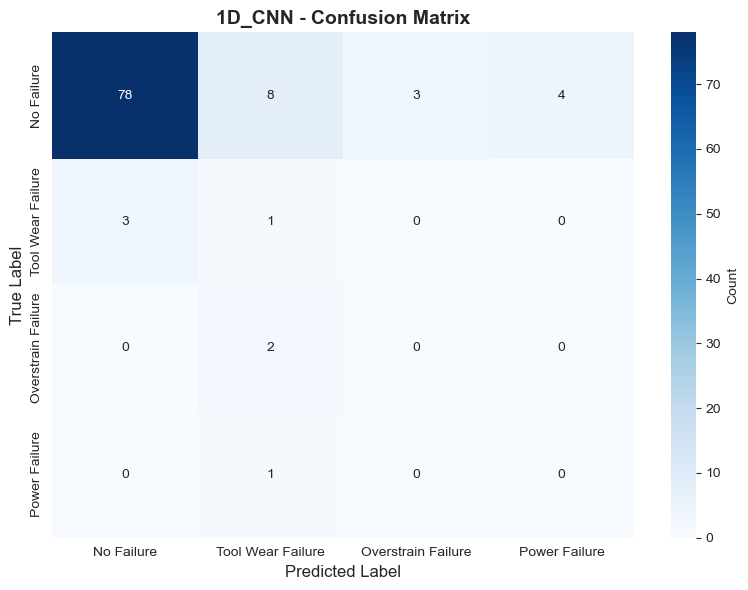


1D_CNN Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.96      0.84      0.90        93
 Tool Wear Failure       0.08      0.25      0.12         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.79       100
         macro avg       0.26      0.27      0.26       100
      weighted avg       0.90      0.79      0.84       100



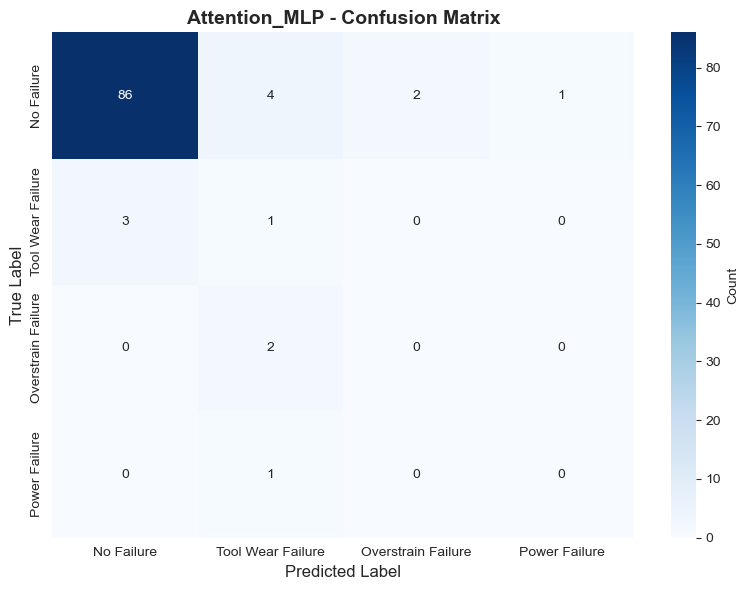


Attention_MLP Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.97      0.92      0.95        93
 Tool Wear Failure       0.12      0.25      0.17         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.87       100
         macro avg       0.27      0.29      0.28       100
      weighted avg       0.90      0.87      0.89       100



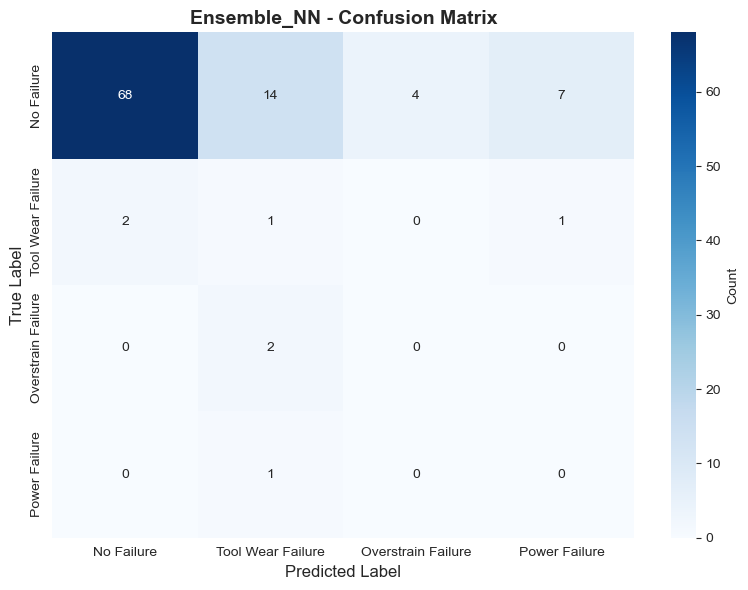


Ensemble_NN Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.97      0.73      0.83        93
 Tool Wear Failure       0.06      0.25      0.09         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.69       100
         macro avg       0.26      0.25      0.23       100
      weighted avg       0.91      0.69      0.78       100



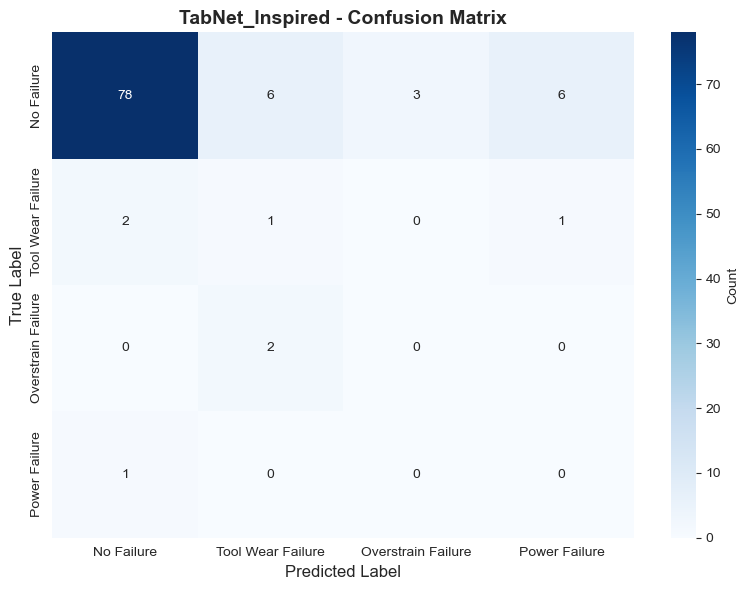


TabNet_Inspired Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.96      0.84      0.90        93
 Tool Wear Failure       0.11      0.25      0.15         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.79       100
         macro avg       0.27      0.27      0.26       100
      weighted avg       0.90      0.79      0.84       100



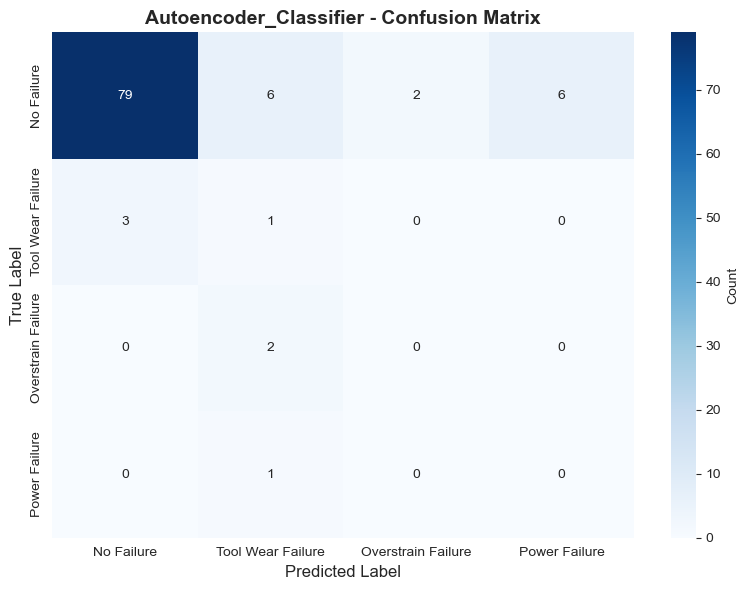


Autoencoder_Classifier Classification Report:
                    precision    recall  f1-score   support

        No Failure       0.96      0.85      0.90        93
 Tool Wear Failure       0.10      0.25      0.14         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.80       100
         macro avg       0.27      0.27      0.26       100
      weighted avg       0.90      0.80      0.85       100



In [16]:
for model_name, result in results.items():
    cm = confusion_matrix(y_test, result['predictions'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'\n{model_name} Classification Report:')
    print('='*60)
    print(classification_report(y_test, result['predictions'], target_names=class_names))


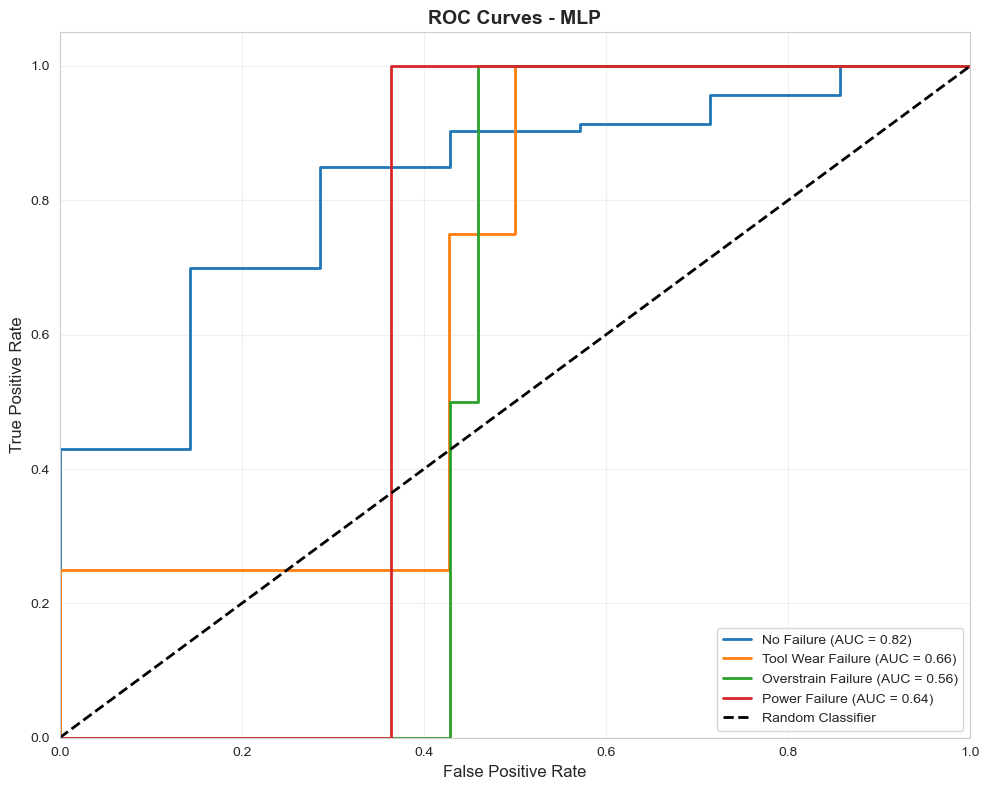

In [17]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - MLP', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Compare with ML Results

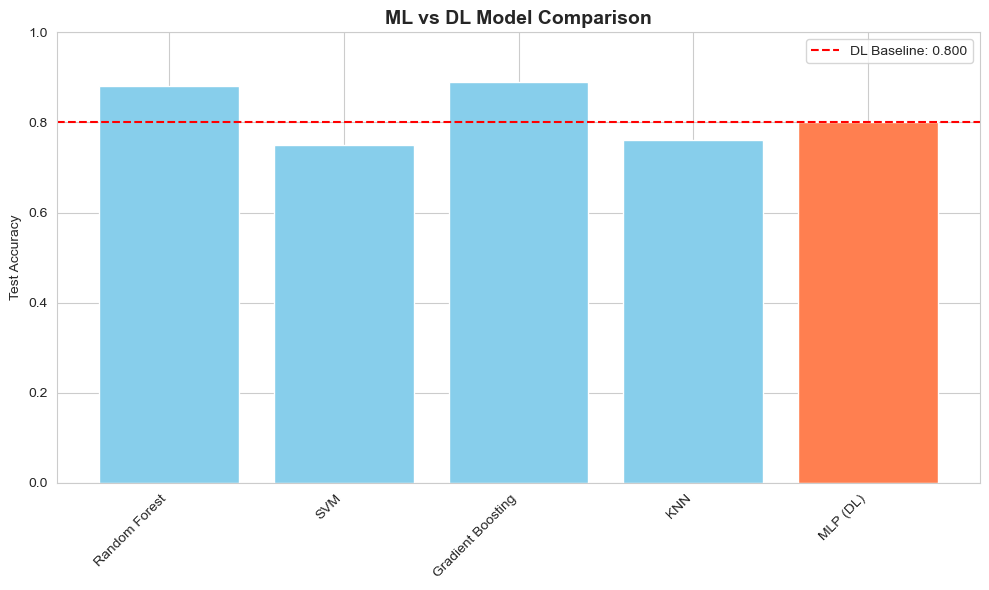


Model Comparison:
            Model  Test Accuracy
    Random Forest           0.88
              SVM           0.75
Gradient Boosting           0.89
              KNN           0.76
         MLP (DL)           0.80


In [18]:
# Load ML results if available
ml_results_path = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_ml\model_comparison.csv'

if os.path.exists(ml_results_path):
    ml_results = pd.read_csv(ml_results_path)
    
    # Add DL result
    dl_result = pd.DataFrame([{
        'Model': 'MLP (DL)',
        'Test Accuracy': test_acc
    }])
    
    comparison = pd.concat([ml_results[['Model', 'Test Accuracy']], dl_result], ignore_index=True)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    colors = ['skyblue'] * len(ml_results) + ['coral']
    plt.bar(comparison['Model'], comparison['Test Accuracy'], color=colors)
    plt.title('ML vs DL Model Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Test Accuracy')
    plt.ylim([0, 1])
    plt.xticks(rotation=45, ha='right')
    plt.axhline(y=test_acc, color='red', linestyle='--', label=f'DL Baseline: {test_acc:.3f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("\nModel Comparison:")
    print(comparison.to_string(index=False))
else:
    print("ML results not found. Run 04_CIA1_ML_training.ipynb first.")

## 7. Save Model

In [19]:
# Save final model
model_path = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_dl\mlp_final.keras'
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save scaler
import joblib
scaler_path = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_dl\scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

print("\nTraining complete!")

Model saved to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_dl\mlp_final.keras
Scaler saved to: d:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\Trained_models\cia1_dl\scaler.pkl

Training complete!


ENSEMBLE METHODS - Combining ML and DL Models

Training ML models for ensemble...
  Training Random_Forest...
    Random_Forest Test Accuracy: 0.8300
  Training SVM...
    SVM Test Accuracy: 0.6300
  Training Gradient_Boosting...
    Gradient_Boosting Test Accuracy: 0.8700
  Training KNN...
    KNN Test Accuracy: 0.7100
  Training XGBoost...


C:\Users\WORKNFLOW\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:38:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    XGBoost Test Accuracy: 0.9000

ML models trained successfully!

ENSEMBLE STRATEGY 1: Simple Voting

Simple Voting Ensemble Accuracy: 0.8400
Number of models in ensemble: 12

ENSEMBLE STRATEGY 2: Weighted Voting

Model Weights (based on test accuracy):
  XGBoost                  : 0.9000
  Gradient_Boosting        : 0.8700
  Attention_MLP            : 0.8700
  Deep_MLP                 : 0.8500
  MLP                      : 0.8400
  Random_Forest            : 0.8300
  Autoencoder_Classifier   : 0.8000
  1D_CNN                   : 0.7900
  TabNet_Inspired          : 0.7900
  KNN                      : 0.7100
  Ensemble_NN              : 0.6900
  SVM                      : 0.6300

Weighted Voting Ensemble Accuracy: 0.8400

ENSEMBLE STRATEGY 3: Soft Voting (Probability Averaging)

Soft Voting Ensemble Accuracy: 0.8600

ENSEMBLE STRATEGY 4: Top-K Best Models

Top 5 models selected:
  XGBoost                  : 0.9000
  Gradient_Boosting        : 0.8700
  Attention_MLP            : 0.8700


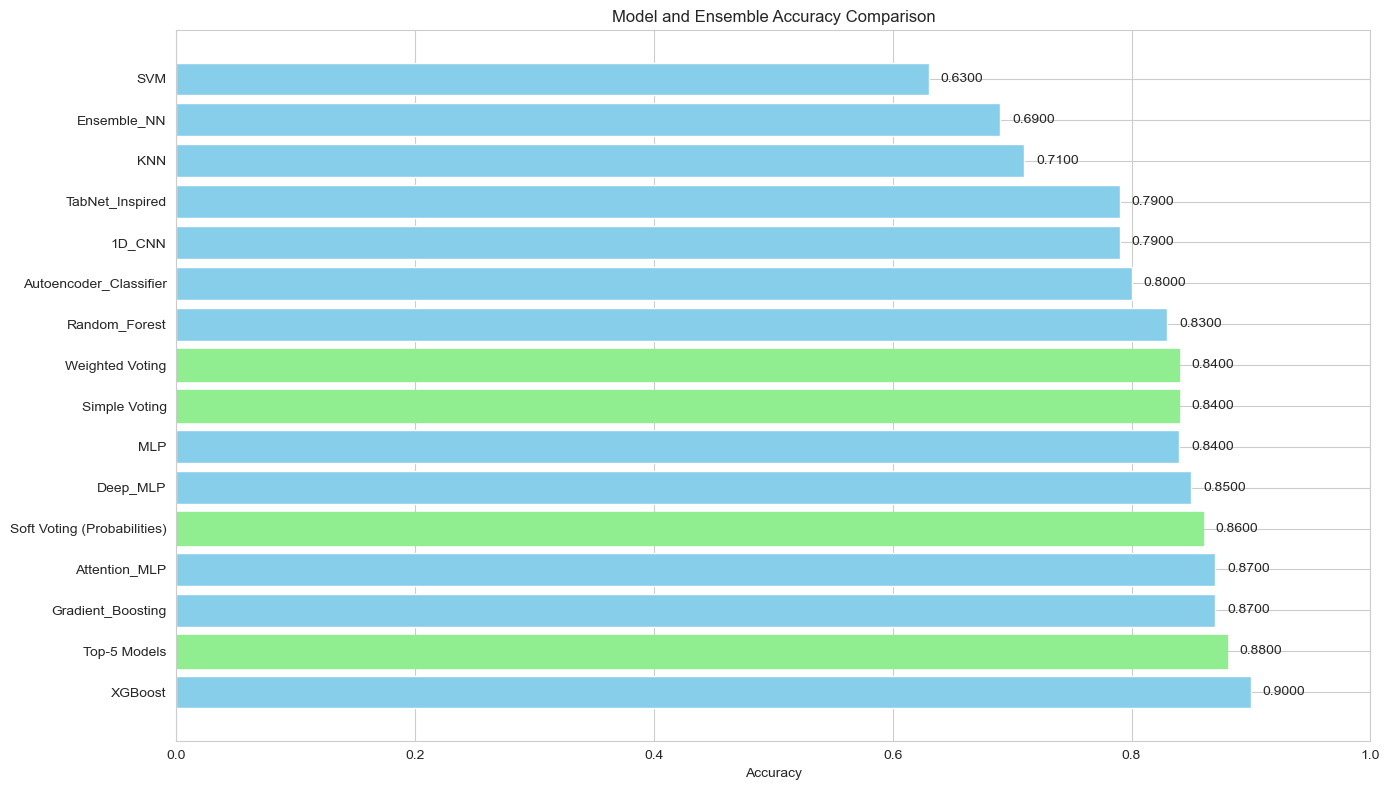

In [20]:
# ==========================================
# ENSEMBLE METHODS - Combining ML and DL Models
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy import stats
import numpy as np

print('='*70)
print('ENSEMBLE METHODS - Combining ML and DL Models')
print('='*70)

# Train ML models
print('\nTraining ML models for ensemble...')
ml_models = {
    'Random_Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    'SVM': SVC(C=1.0, kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Gradient_Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

ml_predictions = {}
ml_probabilities = {}

for name, ml_model in ml_models.items():
    print(f'  Training {name}...')
    ml_model.fit(X_train_scaled, y_train_balanced)
    ml_predictions[name] = ml_model.predict(X_test_scaled)
    if hasattr(ml_model, 'predict_proba'):
        ml_probabilities[name] = ml_model.predict_proba(X_test_scaled)
    ml_acc = (ml_predictions[name] == y_test).mean()
    print(f'    {name} Test Accuracy: {ml_acc:.4f}')

print('\nML models trained successfully!')

# --- Ensemble Strategy 1: Simple Voting ---
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 1: Simple Voting')
print('='*70)

all_predictions = {}
all_predictions.update(ml_predictions)

# Add DL predictions from previous cells
# Assuming 'results' dictionary exists from DL training
for model_name, result in results.items():
    all_predictions[model_name] = result['predictions']

# Simple majority voting
predictions_array = np.array(list(all_predictions.values()))
voting_predictions = stats.mode(predictions_array, axis=0, keepdims=False)[0]
voting_accuracy = (voting_predictions == y_test).mean()

print(f'\nSimple Voting Ensemble Accuracy: {voting_accuracy:.4f}')
print(f'Number of models in ensemble: {len(all_predictions)}')

# --- Ensemble Strategy 2: Weighted Voting ---
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 2: Weighted Voting')
print('='*70)

model_weights = {}
for name, preds in all_predictions.items():
    acc = (preds == y_test).mean()
    model_weights[name] = acc

print('\nModel Weights (based on test accuracy):')
for name, weight in sorted(model_weights.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:25s}: {weight:.4f}')

# Weighted voting
num_classes = len(np.unique(y_test))
weighted_votes = np.zeros((len(y_test), num_classes))
for name, preds in all_predictions.items():
    weight = model_weights[name]
    for i, pred in enumerate(preds):
        weighted_votes[i, pred] += weight

weighted_predictions = np.argmax(weighted_votes, axis=1)
weighted_accuracy = (weighted_predictions == y_test).mean()

print(f'\nWeighted Voting Ensemble Accuracy: {weighted_accuracy:.4f}')

# --- Ensemble Strategy 3: Soft Voting ---
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 3: Soft Voting (Probability Averaging)')
print('='*70)

all_probabilities = {}
all_probabilities.update(ml_probabilities)

# Add DL probabilities
for model_name, result in results.items():
    # Handle reshaping for 1D_CNN if necessary
    if model_name == '1D_CNN':
         if len(X_test_scaled.shape) == 2:
             X_input = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)
         else:
             X_input = X_test_scaled
    else:
         X_input = X_test_scaled
         
    all_probabilities[model_name] = result['model'].predict(X_input, verbose=0)

# Average probabilities
avg_probabilities = np.mean(list(all_probabilities.values()), axis=0)
soft_voting_predictions = np.argmax(avg_probabilities, axis=1)
soft_voting_accuracy = (soft_voting_predictions == y_test).mean()

print(f'\nSoft Voting Ensemble Accuracy: {soft_voting_accuracy:.4f}')

# --- Ensemble Strategy 4: Top-K Models ---
print('\n' + '='*70)
print('ENSEMBLE STRATEGY 4: Top-K Best Models')
print('='*70)

top_k = 5
sorted_models = sorted(model_weights.items(), key=lambda x: x[1], reverse=True)
top_models = dict(sorted_models[:top_k])

print(f'\nTop {top_k} models selected:')
for name, weight in top_models.items():
    print(f'  {name:25s}: {weight:.4f}')

topk_votes = np.zeros((len(y_test), num_classes))
for name in top_models.keys():
    preds = all_predictions[name]
    for i, pred in enumerate(preds):
        topk_votes[i, pred] += 1

topk_predictions = np.argmax(topk_votes, axis=1)
topk_accuracy = (topk_predictions == y_test).mean()

print(f'\nTop-{top_k} Ensemble Accuracy: {topk_accuracy:.4f}')

# --- Summary & Visualization ---
print('\n' + '='*70)
print('ENSEMBLE RESULTS SUMMARY')
print('='*70)

ensemble_results = {
    'Simple Voting': voting_accuracy,
    'Weighted Voting': weighted_accuracy,
    'Soft Voting (Probabilities)': soft_voting_accuracy,
    f'Top-{top_k} Models': topk_accuracy
}

for method, acc in sorted(ensemble_results.items(), key=lambda x: x[1], reverse=True):
    print(f'{method:30s}: {acc:.4f}')

best_ensemble = max(ensemble_results.items(), key=lambda x: x[1])
print(f'\nBest Ensemble Method: {best_ensemble[0]} ({best_ensemble[1]:.4f})')

# Visualization
print('\n' + '='*70)
print('VISUALIZING RESULTS')
print('='*70)

plt.figure(figsize=(14, 8))
plot_data = model_weights.copy()
plot_data.update(ensemble_results)
sorted_plot_data = dict(sorted(plot_data.items(), key=lambda x: x[1], reverse=True))

bars = plt.barh(list(sorted_plot_data.keys()), list(sorted_plot_data.values()), color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model and Ensemble Accuracy Comparison')
plt.xlim(0, 1.0)

for i, (name, acc) in enumerate(sorted_plot_data.items()):
    if name in ensemble_results:
        bars[i].set_color('lightgreen')
    plt.text(acc + 0.01, i, f'{acc:.4f}', va='center')

plt.tight_layout()
plt.show()


# Improved Training Pipeline

This section implements a corrected training pipeline to address data leakage and class imbalance.
It splits the data into Train/Validation/Test sets *before* applying SMOTE, ensuring the validation set remains pure.
It also saves the best performing model for each architecture.

In [21]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Add, Multiply, Dense, Dropout, BatchNormalization, Concatenate

# Add project root to path
sys.path.append(r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes')
from src.data.loaders import CIA1Loader

print("="*80)
print("IMPROVED TRAINING PIPELINE: Fixing Leakage & Saving Best Models")
print("="*80)

# 1. Load Data
data_dir = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\CIA-1_Data'
loader = CIA1Loader(data_dir)
X, y, feature_names = loader.load_data()
class_names = loader.get_class_names()

# 2. Split Data: Train (60%), Validation (20%), Test (20%)
# First split: Train+Val (80%) and Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: Train (75% of 80% = 60%) and Val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Data Split Shapes:")
print(f"  Train (Original): {X_train.shape}")
print(f"  Validation:       {X_val.shape}")
print(f"  Test:             {X_test.shape}")

# 3. Apply SMOTE ONLY to Training Data
print("\nApplying SMOTE to Training Data only...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"  Balanced Train:   {X_train_balanced.shape}")

# 4. Scale Data
# Fit scaler on Balanced Training Data (or just Training Data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert labels to categorical
y_train_cat = to_categorical(y_train_balanced, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

# 5. Model Definitions
def build_mlp(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_deep_mlp(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_1d_cnn(input_dim, num_classes):
    inputs = Input(shape=(input_dim, 1))
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_attention_mlp(input_dim, num_classes):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    attention = Dense(128, activation='tanh')(x)
    attention = Dense(128, activation='softmax')(attention)
    x = Multiply()([x, attention])
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_ensemble_nn(input_dim, num_classes, n_models=3):
    inputs = Input(shape=(input_dim,))
    branches = []
    for i in range(n_models):
        branch = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
        branch = BatchNormalization()(branch)
        branch = Dropout(0.4)(branch)
        branch = Dense(32, activation='relu')(branch)
        branch = Dropout(0.3)(branch)
        branches.append(branch)
    combined = Concatenate()(branches)
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_tabnet_inspired(input_dim, num_classes):
    inputs = Input(shape=(input_dim,))
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    attention = Dense(input_dim, activation='softmax')(x)
    attended_features = Multiply()([inputs, attention])
    x = Concatenate()([x, attended_features])
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_autoencoder_classifier(input_dim, num_classes):
    inputs = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(inputs)
    encoded = BatchNormalization()(encoded)
    encoded = Dropout(0.3)(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    x = Dense(64, activation='relu')(encoded)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 6. Train Models
input_dim = X_train_scaled.shape[1]
num_classes = 4
models = {
    'MLP': build_mlp(input_dim, num_classes),
    'Deep_MLP': build_deep_mlp(input_dim, num_classes),
    '1D_CNN': build_1d_cnn(input_dim, num_classes),
    'Attention_MLP': build_attention_mlp(input_dim, num_classes),
    'Ensemble_NN': build_ensemble_nn(input_dim, num_classes),
    'TabNet_Inspired': build_tabnet_inspired(input_dim, num_classes),
    'Autoencoder_Classifier': build_autoencoder_classifier(input_dim, num_classes)
}

results = {}
save_dir = r'd:\Silas Document\UMaT\Year 4\Project work\Matlab_Project codes\models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for name, model in models.items():
    print(f'\nTRAINING {name}...')
    
    # Prepare inputs
    if name == '1D_CNN':
        X_train_in = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
        X_val_in = X_val_scaled.reshape(-1, X_val_scaled.shape[1], 1)
        X_test_in = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)
    else:
        X_train_in = X_train_scaled
        X_val_in = X_val_scaled
        X_test_in = X_test_scaled
        
    # Callbacks
    checkpoint_path = os.path.join(save_dir, f'best_model_{name}.keras')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)
    ]
    
    # Train
    history = model.fit(
        X_train_in, y_train_cat,
        validation_data=(X_val_in, y_val_cat),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0 # Reduce verbosity for summary
    )
    
    # Evaluate
    loss, acc = model.evaluate(X_test_in, y_test_cat, verbose=0)
    print(f'  Test Accuracy: {acc:.4f}')
    
    # Detailed Report
    y_pred = model.predict(X_test_in, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(classification_report(y_test, y_pred_classes, target_names=class_names, zero_division=0))
    
    results[name] = acc

print("\n" + "="*60)
print("FINAL IMPROVED RESULTS")
print("="*60)
for name, acc in results.items():
    print(f"{name:25s}: {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} with {results[best_model_name]:.4f} accuracy")
print(f"Best model saved to: {os.path.join(save_dir, 'best_model_' + best_model_name + '.keras')}")


IMPROVED TRAINING PIPELINE: Fixing Leakage & Saving Best Models
Loaded CIA-1 Dataset: 500 samples, 9 features
Class distribution: {0: 467, 1: 19, 2: 8, 3: 6}
Data Split Shapes:
  Train (Original): (300, 9)
  Validation:       (100, 9)
  Test:             (100, 9)

Applying SMOTE to Training Data only...
  Balanced Train:   (1120, 9)


C:\Users\WORKNFLOW\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



TRAINING MLP...
  Test Accuracy: 0.7200
                    precision    recall  f1-score   support

        No Failure       0.99      0.76      0.86        93
 Tool Wear Failure       0.08      0.25      0.12         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.72       100
         macro avg       0.27      0.25      0.25       100
      weighted avg       0.92      0.72      0.81       100


TRAINING Deep_MLP...
  Test Accuracy: 0.7600
                    precision    recall  f1-score   support

        No Failure       0.97      0.81      0.88        93
 Tool Wear Failure       0.10      0.25      0.14         4
Overstrain Failure       0.00      0.00      0.00         2
     Power Failure       0.00      0.00      0.00         1

          accuracy                           0.76       100
         macro avg       0.27      0.26      0.26       100
      we